# GAN : Generative Adversarial Network

Deux reseaux jouent l'un contre l'autre :

1. Generateur `G` : bruit `z` -> fausse image. Il veut tromper `D`.
2. Discriminateur `D` : image -> logit (reelle ou fausse). Il veut ne pas etre trompe.

A l'equilibre, `D` ne fait pas mieux que le hasard et `G` produit des images plausibles.

Version implementee : GAN vanilla (Goodfellow, 2014), generateur et discriminateur en couches
denses, binary cross-entropy, sur MNIST.

Le GAN n'a pas d'encodeur : il n'existe aucune fonction `x -> z`. Les trois taches sont traitees
ainsi, la ou deux d'entre elles demandent un detour :

| Tache | Moyen |
|---|---|
| Generation de donnees synthetiques | `generate()` |
| Compression / Decompression | `invert()` puis `decode()`, par descente de gradient sur `z` |
| Projection pour visualisation | `extract_features()`, discriminateur recycle en extracteur |

Les taches 2 et 3 sont evaluees face a une reference : AutoEncoder a dimension latente egale pour
la compression, PCA sur pixels bruts pour la projection.

In [1]:
from src.dataset import load_mnist_dataset
from src.gan import GAN
from src.autoencoder import AutoEncoder
from src.pca import PCA
from src.helper import extract_full_dataset, get_device
from src.metrics import compression_report, Latent

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

np.random.seed(0)
torch.manual_seed(0)

print("device:", get_device())

LATENT_DIM = 100
EPOCHS = 60
BATCH_SIZE = 128
N_EVAL = 1000
N_PROJECTION = 3000
INVERSION_STEPS = 300

device: mps


In [2]:
def flattened_vector_to_image(flat_vector, image_shape):
    channels, height, width = image_shape
    image = flat_vector.reshape(channels, height, width)
    return image[0] if channels == 1 else np.transpose(image, (1, 2, 0))

def show_image_grid(samples, image_shape, n_rows=2, n_cols=8, title=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.3, n_rows * 1.5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(np.clip(flattened_vector_to_image(samples[i], image_shape), 0, 1), cmap=cmap)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

def show_original_vs_reconstruction_grid(originals, reconstructions, image_shape, n=8, title=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(2, n, figsize=(n * 1.3, 3))
    for i in range(n):
        axes[0, i].imshow(flattened_vector_to_image(originals[i], image_shape), cmap=cmap)
        axes[1, i].imshow(np.clip(flattened_vector_to_image(reconstructions[i], image_shape), 0, 1), cmap=cmap)
        axes[0, i].axis("off"); axes[1, i].axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

## Partie A - MNIST DIGITS

train: (60000, 784) | valeurs dans (0.0, 1.0)


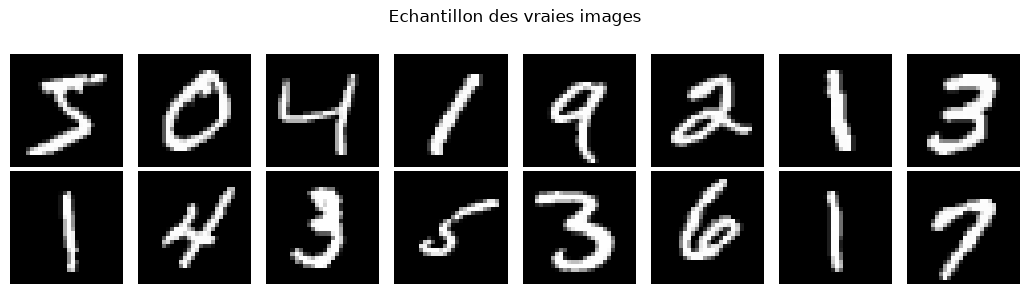

In [3]:
mnist_images, mnist_labels = extract_full_dataset(load_mnist_dataset(train=True, shuffle=False))

MNIST_SHAPE = (1, 28, 28)
X_mnist = mnist_images.flatten(start_dim=1).numpy()
y_mnist = mnist_labels.numpy()

print("train:", X_mnist.shape, "| valeurs dans", (float(X_mnist.min()), float(X_mnist.max())))
show_image_grid(X_mnist, MNIST_SHAPE, title="Echantillon des vraies images")

### Protocole d'entrainement

Chaque batch enchaine deux pas de descente de gradient.

**1. Pas sur `D`** (vraies -> 1, fausses -> 0). `G` doit rester fige : le batch genere passe par
`.detach()`, qui coupe le graphe et empeche le gradient de remonter jusqu'a ses poids.

**2. Pas sur `G`** (fausses -> 1, du point de vue de `D`). Symetriquement, `D` est gele via
`set_requires_grad(discriminator, False)`. Le gradient doit **traverser** `D` pour atteindre `G`,
mais ne doit pas modifier ses poids. Sans ce gel, `D` accumulerait des gradients issus d'une loss
qui cherche a le tromper.

**Loss et saturation.** La formulation d'origine fait minimiser `log(1 - D(G(z)))` a `G`. Quand `D`
rejette une fausse image avec confiance, la derivee de ce terme tend vers 0 : `G` cesse d'apprendre
precisement quand il est le plus mauvais. On utilise donc la forme **non saturante**, `G` maximise
`log D(G(z))`, ce qui s'ecrit `BCE(D(fake), 1)`. `BCEWithLogitsLoss` est prefere a
`Sigmoid + BCELoss` : le log-sum-exp est calcule de facon stable, un logit tres confiant ne produit
pas un gradient nul par arrondi.

**Sampling.** Les batchs sont melanges (`shuffle=True`) : tries par classe, ils donneraient a `D`
une statistique de lot a exploiter au lieu de juger chaque image. `drop_last=True` ecarte le dernier
batch incomplet, qui fausserait les moyennes de fin d'epoch. Les images sont mises a l'echelle de
`[0, 1]` vers `[-1, 1]` en interne pour correspondre au Tanh de sortie de `G`.

Pas de split train/eval pour l'entrainement : il n'y a pas de reconstruction a valider. Le split
reapparait a la tache 2, ou l'on inverse des images pour mesurer une MSE.

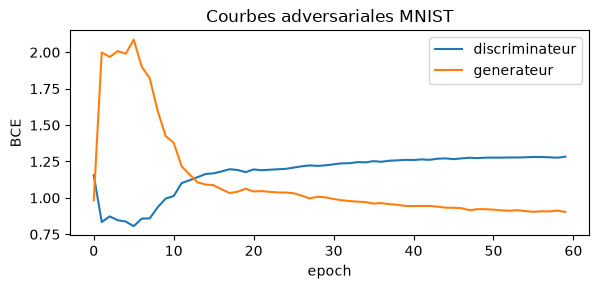

In [4]:
gan = GAN(data_dim=784, latent_dim=LATENT_DIM)
gan.fit(X_mnist, epochs=EPOCHS, batch_size=BATCH_SIZE)

plt.figure(figsize=(6, 3))
plt.plot(gan.loss_history["discriminator"], label="discriminateur")
plt.plot(gan.loss_history["generator"], label="generateur")
plt.xlabel("epoch"); plt.ylabel("BCE"); plt.title("Courbes adversariales MNIST")
plt.legend(); plt.tight_layout(); plt.show()

### Lecture des courbes

Une loss qui descend n'est pas un bon signe : les deux reseaux optimisent des objectifs opposes,
la somme ne peut pas tendre vers zero.

- Les deux courbes oscillent autour d'un plateau : le jeu est equilibre.
- La loss de `D` tombe vers 0 et celle de `G` explose : `D` a gagne, `G` n'a plus de gradient.
- La loss de `G` s'effondre : `G` a trouve une faille, souvent un signe de mode collapse.

Ici les deux courbes se croisent vers l'epoch 12 puis se stabilisent.

Le deuxieme scenario s'est produit pendant le developpement (`journal_dev_gan.md`, entree du
16/07 15:30) : sans `Dropout` dans `D`, loss de `D` a 0.0 et loss de `G` a 13.5, images reduites a
des taches. Quand la generation est mauvaise, ce n'est pas `G` qu'il faut renforcer mais souvent
`D` qu'il faut affaiblir.

### Metriques d'equilibre

Les loss seules ne disent pas si la partie est equilibree. Deux indicateurs le disent :

- **accuracy de `D`** sur un lot moitie vraies moitie fausses. A 0.5, `D` ne fait pas mieux que le
  hasard : `G` produit des images qu'il ne sait plus distinguer des vraies.
- **variance des images generees** au sein d'un batch. Elle doit rester elevee ; un effondrement
  signale un mode collapse.

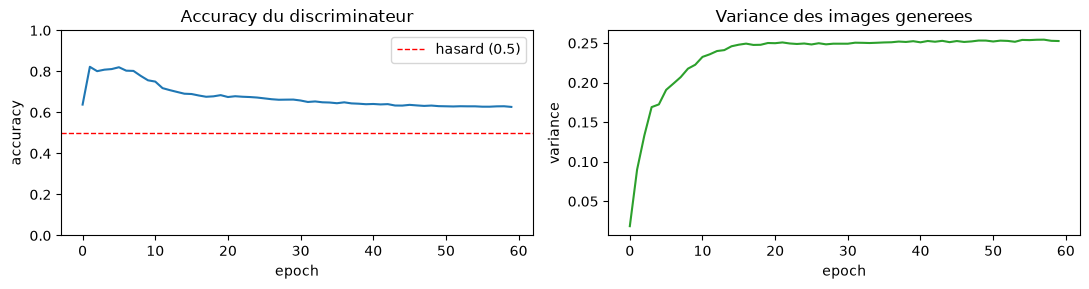

accuracy finale de D: 0.627
variance finale de G: 0.2526


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

axes[0].plot(gan.metric_history["discriminator_accuracy"])
axes[0].axhline(0.5, color="red", ls="--", lw=1, label="hasard (0.5)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy"); axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy du discriminateur"); axes[0].legend()

axes[1].plot(gan.metric_history["generator_variance"], color="tab:green")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("variance")
axes[1].set_title("Variance des images generees")

plt.tight_layout(); plt.show()

print("accuracy finale de D:", round(gan.metric_history["discriminator_accuracy"][-1], 3))
print("variance finale de G:", round(gan.metric_history["generator_variance"][-1], 4))

Lecture : l'accuracy de `D` monte a 0.82 vers l'epoch 5, il domine largement au demarrage face
a un `G` encore incapable. Elle redescend ensuite regulierement et plafonne a **0.63**, au-dessus
du 0.5 ideal : `G` a repris la main sans arriver a tromper `D` une fois sur deux. La partie est
jouable mais reste a l'avantage de `D`, ce qui laisse une marge de progression (`G` plus large,
entrainement plus long, ou architecture convolutive).

La variance des images generees monte de 0.02 a 0.25 puis plafonne : `G` couvre un espace large et
s'y maintient, pas de mode collapse.

Precision de mesure : l'accuracy est relevee pendant l'entrainement, `Dropout` actif. Elle
sous-estime donc le pouvoir discriminant reel de `D`, qui serait plus eleve en `eval()`.

## Tache 1 - Generation de donnees synthetiques

shape: (16, 784) | valeurs dans (0.0, 1.0)


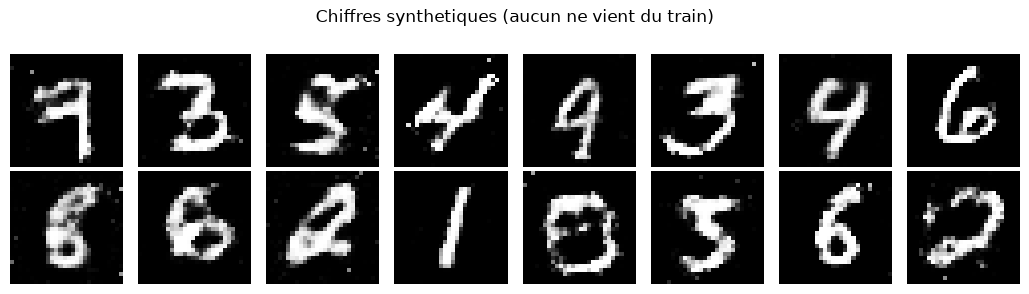

In [6]:
fake_mnist = gan.generate(16, seed=0)
print("shape:", fake_mnist.shape, "| valeurs dans", (round(float(fake_mnist.min()), 3), round(float(fake_mnist.max()), 3)))
show_image_grid(fake_mnist, MNIST_SHAPE, title="Chiffres synthetiques (aucun ne vient du train)")

### Verification du mode collapse

Risque : `G` trouve une image qui trompe `D` et ne produit plus qu'elle. On genere un lot large et
on compare l'ecart-type pixel a pixel entre images a celui des vraies donnees.

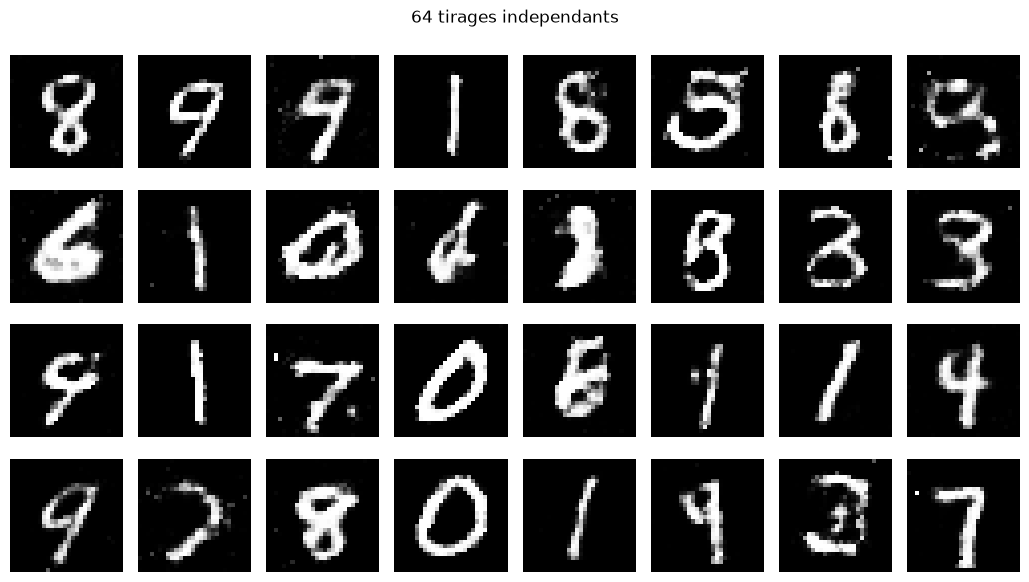

ecart-type inter-images (genere): 0.1754


ecart-type inter-images (reel)  : 0.1932


In [7]:
sample_batch = gan.generate(64, seed=1)
show_image_grid(sample_batch, MNIST_SHAPE, n_rows=4, n_cols=8, title="64 tirages independants")

print("ecart-type inter-images (genere):", round(float(sample_batch.std(axis=0).mean()), 4))
print("ecart-type inter-images (reel)  :", round(float(X_mnist.std(axis=0).mean()), 4))

### Structure de l'espace latent

Interpolation lineaire entre deux bruits `z_a` et `z_b`, chaque etape decodee. Des chiffres
plausibles tout au long du chemin indiquent une variete continue apprise, et non une memorisation
du train.

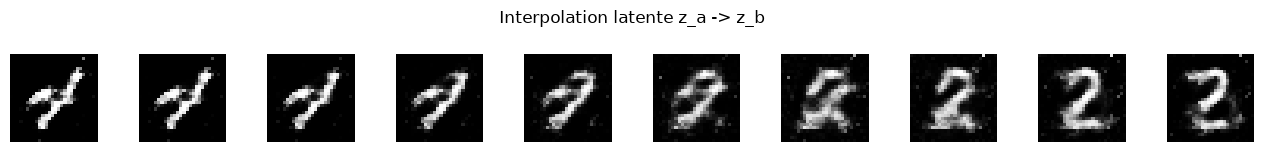

In [8]:
def interpolate_latent(gan, n_steps=10, seed=2):
    # -> (n_steps, data_dim) : chemin de z_a vers z_b decode par le generateur
    torch.manual_seed(seed)
    z_a, z_b = gan.sample_noise(1), gan.sample_noise(1)
    weights = torch.linspace(0, 1, n_steps, device=gan.device).unsqueeze(1)
    path = (1 - weights) * z_a + weights * z_b
    return gan.decode(Latent(array=path.cpu().numpy(), nature="continuous"))

walk = interpolate_latent(gan, n_steps=10)
show_image_grid(walk, MNIST_SHAPE, n_rows=1, n_cols=10, title="Interpolation latente z_a -> z_b")

## Tache 2 - Compression / Decompression

Le generateur est un decodeur `z -> x`, mais rien ne code une image existante. Pour obtenir son
code latent il faut le **chercher** : `G` est fige et une descente de gradient est menee sur `z`
lui-meme pour minimiser `||G(z) - x||`. C'est `GAN.invert()`.

Ce n'est pas un encodeur : l'AutoEncoder code une image en une passe avant, ici il faut 300 pas de
gradient.

code latent par image: 100 valeurs | nature: continuous


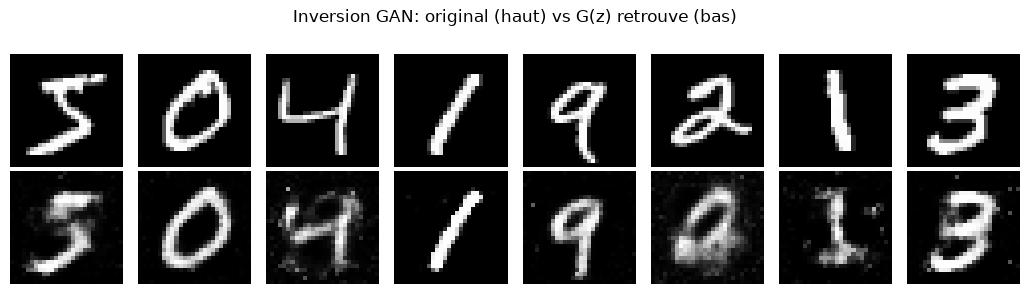

In [9]:
X_eval = X_mnist[:N_EVAL]

gan_latent = gan.invert(X_eval, steps=INVERSION_STEPS, seed=0)
gan_reconstructed = gan.decode(gan_latent)
print("code latent par image:", gan_latent.array.shape[1], "valeurs | nature:", gan_latent.nature)

show_original_vs_reconstruction_grid(X_eval, gan_reconstructed, MNIST_SHAPE, n=8,
                     title="Inversion GAN: original (haut) vs G(z) retrouve (bas)")

L'inversion retrouve la plupart des chiffres, mais certains echouent et degenerent en tache.
Ces images n'ont aucun antecedent dans l'espace latent : `G` est incapable de les produire quel que
soit `z`.

Un AutoEncoder reconstruit toujours quelque chose de l'entree, meme flou, ayant ete entraine a
couvrir toutes les donnees. Le GAN n'a pas cette contrainte, il lui suffit de tromper `D`, et peut
donc ignorer une partie du dataset sans etre penalise (mode dropping).

In [10]:
gan_report = compression_report(gan.get_codebook(), gan_latent, X_eval, gan_reconstructed)

# Reference a dimension latente identique
autoencoder = AutoEncoder(
    input_dim=784, output_dim=784, latent_dim=LATENT_DIM,
    encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU, fonction_loss=nn.MSELoss
)
autoencoder.fit(X_mnist[:15000], epochs=15, batch_size=BATCH_SIZE)
ae_latent = autoencoder.encode(X_eval)
ae_reconstructed = autoencoder.decode(ae_latent)
ae_report = compression_report(autoencoder.get_codebook(), ae_latent, X_eval, ae_reconstructed)

print(f"{'critere':<26}{'GAN':>14}{'AutoEncoder':>16}")
for key in ["reconstruction_mse", "codebook_bytes", "latent_bytes", "compression_ratio"]:
    fmt = lambda v: f"{v:.4f}" if isinstance(v, float) else str(v)
    print(f"{key:<26}{fmt(gan_report[key]):>14}{fmt(ae_report[key]):>16}")

critere                              GAN     AutoEncoder
reconstruction_mse                0.0209          0.0105
codebook_bytes                   5945408         1632336
latent_bytes                      400000          400000
compression_ratio                 0.4942          1.5431


### Un ratio de compression inferieur a 1

Sur ce lot le GAN gonfle les donnees au lieu de les compresser : son codebook (les poids de `G`)
pese davantage que les 1000 images d'origine.

Ce cout est fixe, paye une fois puis amorti sur toutes les images transmises. La question devient
donc : a partir de combien d'images le codage devient-il rentable ? Les tailles etant lineaires en
`N`, le ratio se calcule analytiquement.

le GAN devient rentable au-dela de 2173 images
plafond theorique (codebook amorti): 7.84


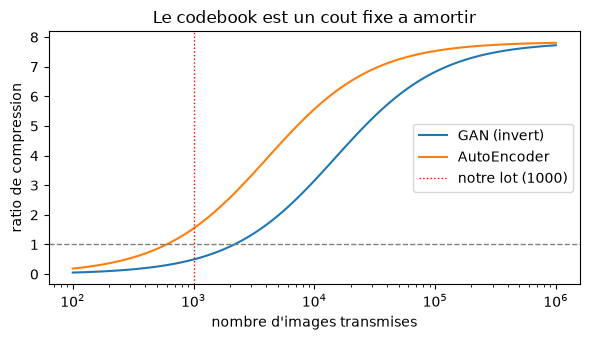

In [11]:
def compression_ratio_curve(codebook_bytes, latent_dim, data_dim, n_images):
    # -> (len(n_images),) : ratio original / (codebook + latent) en fonction du nombre d'images
    original = n_images * data_dim * 4
    compressed = codebook_bytes + n_images * latent_dim * 4
    return original / compressed

n_images = np.logspace(2, 6, 100)
gan_curve = compression_ratio_curve(gan_report["codebook_bytes"], LATENT_DIM, 784, n_images)
ae_curve = compression_ratio_curve(ae_report["codebook_bytes"], LATENT_DIM, 784, n_images)

# Seuil de rentabilite : ratio = 1, soit codebook = N * (gain par image)
gan_break_even = gan_report["codebook_bytes"] / ((784 - LATENT_DIM) * 4)
print("le GAN devient rentable au-dela de", int(gan_break_even), "images")
print("plafond theorique (codebook amorti):", round(784 / LATENT_DIM, 2))

plt.figure(figsize=(6, 3.5))
plt.plot(n_images, gan_curve, label="GAN (invert)")
plt.plot(n_images, ae_curve, label="AutoEncoder")
plt.axhline(1, color="grey", ls="--", lw=1)
plt.axvline(N_EVAL, color="red", ls=":", lw=1, label=f"notre lot ({N_EVAL})")
plt.xscale("log"); plt.xlabel("nombre d'images transmises"); plt.ylabel("ratio de compression")
plt.title("Le codebook est un cout fixe a amortir")
plt.legend(); plt.tight_layout(); plt.show()

## Tache 3 - Projection pour visualisation

Le generateur ne projette rien. Le discriminateur, lui, prend une image en entree et s'est
construit des descripteurs internes pour juger du vrai/faux : ses couches peuvent servir
d'extracteur de features, usage introduit par Radford et al. (DCGAN, 2016).

`extract_features()` renvoie la derniere couche cachee de `D` (256 dimensions), projetee ensuite en
2D par PCA. Reference : PCA appliquee directement aux pixels bruts.

features de D: (3000, 256)


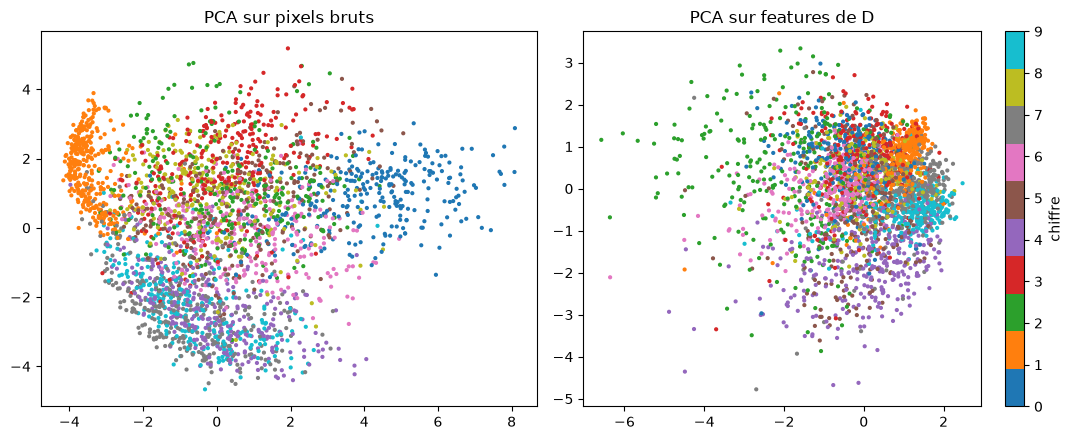

In [12]:
X_proj, y_proj = X_mnist[:N_PROJECTION], y_mnist[:N_PROJECTION]

discriminator_features = gan.extract_features(X_proj)
print("features de D:", discriminator_features.shape)

z_features = PCA(n_components=2).fit(discriminator_features).encode(discriminator_features).array
z_pixels = PCA(n_components=2).fit(X_proj).encode(X_proj).array

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, projection, title in [(axes[0], z_pixels, "PCA sur pixels bruts"),
                              (axes[1], z_features, "PCA sur features de D")]:
    scatter = ax.scatter(projection[:, 0], projection[:, 1], c=y_proj, cmap="tab10", s=4)
    ax.set_title(title)
plt.colorbar(scatter, ax=axes[1], label="chiffre")
plt.tight_layout(); plt.show()

Les couleurs sont les vraies etiquettes, jamais vues par le GAN : elles ne servent qu'a juger
la projection a posteriori. Separabilite quantifiee par un kNN entraine sur les 2 composantes.

In [13]:
for name, projection in [("pixels bruts", z_pixels), ("features de D", z_features)]:
    accuracy = cross_val_score(KNeighborsClassifier(15), projection, y_proj, cv=3).mean()
    print(f"kNN sur 2 composantes ({name:<14}): {accuracy:.3f}")

kNN sur 2 composantes (pixels bruts  ): 0.441
kNN sur 2 composantes (features de D ): 0.430


Les features de `D` font legerement moins bien que les pixels bruts, et le nuage est plus
informe. `D` a ete entraine a separer "reelle" de "fausse", pas a separer les chiffres : rien dans
sa loss ne l'encourage a distinguer un 3 d'un 8, les deux etant de vraies images.

Pour la visualisation, la PCA et l'AutoEncoder restent les outils adaptes.

## Synthese

| Tache | Verdict | Mesure |
|---|---|---|
| Generation | Adapte | Chiffres nets et varies, ecart-type inter-images 0.175 contre 0.193 au reel, variance de `G` stable a 0.25 |
| Compression | Possible mais couteux et incomplet | MSE 2x celle de l'AE a latent egal, 300 pas de gradient par lot au lieu d'une passe, ratio < 1 sous ~2200 images, certaines images sans antecedent latent |
| Projection | Non adapte | kNN 0.43 sur les features de `D` contre 0.44 sur les pixels bruts |

Le GAN est specialise sur la generation et sacrifie les deux autres taches. La contrepartie est
reelle : il produit des images nettes la ou un AutoEncoder rend du flou. L'AE minimise une MSE,
donc en cas de doute il moyenne les sorties possibles, et une moyenne d'images est floue. Le GAN
n'a pas de MSE a minimiser, il doit seulement produire ce que `D` juge credible, et une image
moyennee ne trompe pas `D`.

Le prix est l'absence de garantie de couverture, visible a l'inversion : des chiffres reels n'ont
aucun antecedent dans l'espace latent. Et son entrainement se surveille a l'accuracy de `D` et a
l'oeil, pas a la loss. Sur ce point l'equilibre reste imparfait, `D` conservant l'avantage a 0.63
d'accuracy contre 0.5 vise : c'est la premiere piste a creuser avant de passer au dataset suivant.

Prochaine etape : rejouer ce protocole sur le dataset shapes couleur (32x32x3 = 3072 dimensions).